# Multi-Class Pneumonia Classification with Explainable AI (Grad-CAM)

## Notebook 03: Model Training

### Objectives

This notebook trains an EfficientNet-B2 model using the processed multi-class Chest X-ray dataset.

The notebook performs the following tasks:

- Load the processed dataset
- Apply data augmentation
- Create DataLoaders
- Initialize the EfficientNet-B2 model
- Train and validate the model
- Save the best-performing model
- Save checkpoints for resume training
- Save training history
- Evaluate the trained model

## Import Required Libraries

In [3]:
# ============================================================
# Import Required Libraries
# ============================================================

import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid", context="notebook")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## Project Paths

In [24]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path(
    "/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI"
)

DATASET_DIR = PROJECT_ROOT / "dataset" / "processed_dataset"

MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "best_model.pth"
CHECKPOINT_PATH = MODELS_DIR / "last_checkpoint.pth"

HISTORY_PATH = RESULTS_DIR / "training_history.csv"

print(PROJECT_ROOT)

/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI


## Device Configuration

In [25]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print("CUDA :", torch.version.cuda)

print("="*60)

Device : cuda
GPU : NVIDIA GeForce RTX 3050
CUDA : 12.6


## Reproducibility

In [26]:
# ============================================================
# Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Seed :", SEED)

Seed : 42


## Training Configuration

In [27]:
# ============================================================
# Hyperparameters
# ============================================================

IMAGE_SIZE = 260

BATCH_SIZE = 16

EPOCHS = 30

LEARNING_RATE = 1e-4

NUM_CLASSES = 3

NUM_WORKERS = 4

CLASS_NAMES = [
    "BACTERIA",
    "NORMAL",
    "VIRUS"
]

print("="*60)

print(f"Image Size    : {IMAGE_SIZE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Learning Rate : {LEARNING_RATE}")

print("="*60)

Image Size    : 260
Batch Size    : 16
Epochs        : 30
Learning Rate : 0.0001


## Data Augmentation

Apply data augmentation to the training dataset and standard preprocessing to the validation and test datasets.

In [8]:
# ============================================================
# Data Transformations
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Data transformations created successfully.")

✅ Data transformations created successfully.


## Create Dataset Objects

Load the processed dataset using the ImageFolder class.

In [9]:
# ============================================================
# Load Datasets
# ============================================================

train_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "train",
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "validation",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    root=DATASET_DIR / "test",
    transform=valid_transform
)

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


## Verify Dataset Information

Display the number of images and class mappings.

In [10]:
# ============================================================
# Dataset Information
# ============================================================

print("=" * 60)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(validation_dataset)}")
print(f"Test Images       : {len(test_dataset)}")

print("\nClass Mapping")

for idx, cls in train_dataset.class_to_idx.items():
    print(f"{cls:<12} -> {idx}")

print("=" * 60)

Training Images   : 4099
Validation Images : 878
Test Images       : 879

Class Mapping
0            -> BACTERIA
1            -> NORMAL
2            -> VIRUS


## Create DataLoaders

Create PyTorch DataLoaders for efficient mini-batch loading.

In [11]:
# ============================================================
# Create DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("✅ DataLoaders created successfully.")

✅ DataLoaders created successfully.


## Visualize a Training Batch

Display a sample batch of training images after preprocessing.

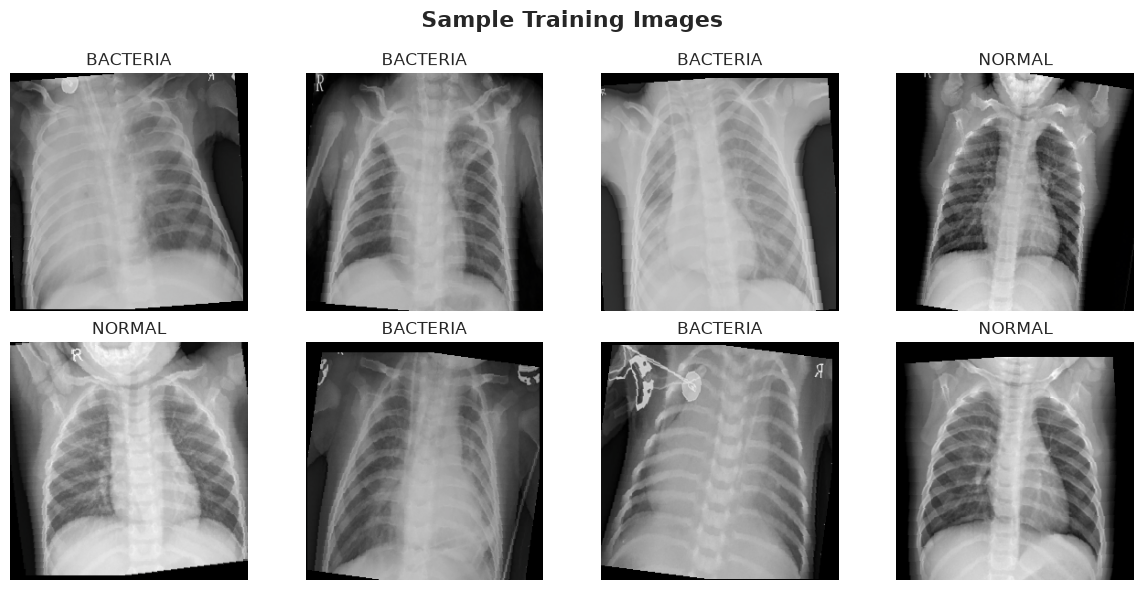

In [12]:
# ============================================================
# Visualize Training Batch
# ============================================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(axes.flat, images[:8], labels[:8]):

    image = image.permute(1, 2, 0).numpy()

    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")

plt.suptitle(
    "Sample Training Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Create EfficientNet Model

Initialize the pretrained EfficientNet model and modify the final classification layer for three-class pneumonia classification.

In [13]:
# ============================================================
# Create EfficientNet-B2 Model
# ============================================================

from torchvision.models import (
    efficientnet_b2,
    EfficientNet_B2_Weights
)

weights = EfficientNet_B2_Weights.DEFAULT

model = efficientnet_b2(weights=weights)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model.classifier)
print("\n✅ EfficientNet-B2 initialized successfully.")

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

✅ EfficientNet-B2 initialized successfully.


## Compute Class Weights

Calculate class weights to reduce the effect of class imbalance during training.

In [14]:
# ============================================================
# Compute Class Weights
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print(class_weights)

tensor([0.7021, 1.2332, 1.3075], device='cuda:0')


## Define Loss Function, Optimizer and Learning Rate Scheduler

In [15]:
# ============================================================
# Training Components
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("✅ Loss Function Created")
print("✅ Optimizer Created")
print("✅ Scheduler Created")

✅ Loss Function Created
✅ Optimizer Created
✅ Scheduler Created


## Mixed Precision Training

Enable Automatic Mixed Precision (AMP) for faster GPU training and lower memory usage.

In [16]:
# ============================================================
# Mixed Precision
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("AMP Enabled :", torch.cuda.is_available())

AMP Enabled : True


## Training Configuration

Initialize variables for model checkpointing, early stopping and training history.

In [17]:
# ============================================================
# Training Variables
# ============================================================

best_accuracy = 0.0

best_epoch = 0

early_stop_counter = 0

EARLY_STOPPING_PATIENCE = 7

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": []
}

print("✅ Training configuration completed.")

✅ Training configuration completed.


## Training and Validation Functions

Define reusable functions for training and validating the model for one epoch.

In [18]:
# ============================================================
# Train One Epoch
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, scaler):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## Validation Function

In [19]:
# ============================================================
# Validate One Epoch
# ============================================================

def validate_one_epoch(model, dataloader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## Checkpoint Utilities

Save and load training checkpoints for resuming interrupted training sessions.

In [20]:
# ============================================================
# Checkpoint Functions
# ============================================================

CHECKPOINT_PATH = MODELS_DIR / "last_checkpoint.pth"
BEST_MODEL_PATH = MODELS_DIR / "best_model.pth"
HISTORY_PATH = RESULTS_DIR / "training_history.csv"


def save_checkpoint(epoch, best_accuracy):

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_accuracy": best_accuracy
    }

    torch.save(checkpoint, CHECKPOINT_PATH)


def save_best_model():

    torch.save(model.state_dict(), BEST_MODEL_PATH)

In [23]:
import torch

checkpoint_path = MODELS_DIR / "last_checkpoint.pth"

try:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    print("✅ Checkpoint loaded successfully!")
    print(checkpoint.keys())

except Exception as e:
    print("❌ Checkpoint is corrupted.")
    print(e)

❌ Checkpoint is corrupted.
PytorchStreamReader failed reading zip archive: failed finding central directory. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.


## Resume Training

Resume training from the last saved checkpoint if available.

In [22]:
START_EPOCH = 0

RESUME_TRAINING = True

if RESUME_TRAINING and CHECKPOINT_PATH.exists():

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state_dict"]
    )

    START_EPOCH = checkpoint["epoch"] + 1

    best_accuracy = checkpoint["best_accuracy"]

    print(f"✅ Resuming from Epoch {START_EPOCH}")

else:

    print("Starting a new training session.")

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.

In [ ]:
    # Load previous history
    if HISTORY_PATH.exists():

        history_df = pd.read_csv(HISTORY_PATH)

        history = {
            "epoch": history_df["epoch"].tolist(),
            "train_loss": history_df["train_loss"].tolist(),
            "train_accuracy": history_df["train_accuracy"].tolist(),
            "validation_loss": history_df["validation_loss"].tolist(),
            "validation_accuracy": history_df["validation_accuracy"].tolist(),
        }

        print("✅ Previous training history loaded.")

NameError: name 'HISTORY_PATH' is not defined

## Model Training

Train the model using the prepared dataset while automatically saving checkpoints, the best-performing model, and training history.